In [ ]:
# !pip install -q langchain langchain-google-genai langgraph pydantic langchain-openai tavily

In [ ]:
# pip install langchain_tavily

In [ ]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI

In [ ]:
from google.colab import userdata

In [ ]:
api_key = userdata.get("GEMINI_API_KEY")

In [ ]:
model = ChatGoogleGenerativeAI(
    model = "gemini-3.5-flash",
    temperature = 0,
    api_key = api_key,
    # max_output_tokens = 100
)

In [ ]:
prompt = "can u explain me about quantum computing"

In [ ]:
response = model.invoke(prompt)

In [ ]:
response

AIMessage(content=[{'type': 'text', 'text': 'To understand quantum computing, it helps to first look at the computer or phone you are using right now. \n\nYour current computer is a **classical computer**. It thinks in black and white. Quantum computers, on the other hand, think in shades of gray—and every other color imaginable, all at once.\n\nHere is a breakdown of how quantum computing works, why it’s a game-changer, and what it can be used for.\n\n---\n\n### 1. The Core Difference: Bits vs. Qubits\n\n*   **Classical Computers use "Bits":** A standard computer chip uses tiny switches called bits. A bit can only be in one of two positions: **0 (Off) or 1 (On)**. Everything your computer does—from sending an email to playing a video game—is just billions of 1s and 0s being processed.\n*   **Quantum Computers use "Qubits" (Quantum Bits):** Because of the laws of physics at the atomic level, a qubit doesn\'t have to be just a 0 or a 1. It can be **both 0 and 1 at the same time**. \n\n#

In [ ]:
response.content[0]['text']

'To understand quantum computing, it helps to first look at the computer or phone you are using right now. \n\nYour current computer is a **classical computer**. It thinks in black and white. Quantum computers, on the other hand, think in shades of gray—and every other color imaginable, all at once.\n\nHere is a breakdown of how quantum computing works, why it’s a game-changer, and what it can be used for.\n\n---\n\n### 1. The Core Difference: Bits vs. Qubits\n\n*   **Classical Computers use "Bits":** A standard computer chip uses tiny switches called bits. A bit can only be in one of two positions: **0 (Off) or 1 (On)**. Everything your computer does—from sending an email to playing a video game—is just billions of 1s and 0s being processed.\n*   **Quantum Computers use "Qubits" (Quantum Bits):** Because of the laws of physics at the atomic level, a qubit doesn\'t have to be just a 0 or a 1. It can be **both 0 and 1 at the same time**. \n\n#### The Coin Analogy:\n*   **Classical Bit:*

In [ ]:
response = model.invoke("should i bring umbrealla tomorrow on 24 sep 2026")

In [ ]:
response.content[0]['text']

'I cannot provide a weather forecast for September 24, 2026. To get an accurate forecast, you will need to check a local weather service or app closer to that date and specify your location.'

In [ ]:
response = model.invoke("hello my name is aditya")
response.content[0]['text']

'Hello Aditya! Nice to meet you. How can I help you today?'

In [ ]:
response = model.invoke("what is my name")
response.content[0]['text']

"I don't know your name yet! Since I don't have access to your personal information, you can tell me what you'd like me to call you. What is your name?"

In [ ]:
# Agent -> tool use

In [ ]:
from langchain_tavily import TavilySearch

In [ ]:
tavily_api_key = userdata.get("TAVILY_API_KEY")

In [ ]:
# setup tool
search_tool = TavilySearch(max_results = 3,
                           tavily_api_key = tavily_api_key)

In [ ]:
tools = [search_tool]

In [ ]:
search_tool.invoke("should i bring umbrealla tomorrow on 24 sep 2026"
"i live in pune")

{'query': 'should i bring umbrealla tomorrow on 24 sep 2026i live in pune',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.instagram.com/reel/DaiHFecsHqh?hl=en',
   'title': 'Instagram',
   'content': "Video by Matching Woman - Trending Fabrics, Designing & Stitching on September 20, 2026. May be an image of motorcycle, signboard, scooter, street, road, night and text that says 'Looking for the perfect FABRICSTORE FABRIC STORE INPUNE IN PUNE 9383 6NH12X 85325'.\n\nVideo by Matching Woman - Trending Fabrics, Designing & Stitching on September 19, 2026. May be an image of text that says 'a DYEABLE HEAVY FABRIC FABRIC IS HERE! Buy Fabric Online www.matchingwoman.in .in ch a 3B sLa'. [...] ⚠️ PUNE HIGH ALERT | 9–12 JULY 🌧️  \n  \nPunekars, the next few days could bring heavy rainfall, waterlogging, traffic congestion, and possible flooding in low-lying areas. If you’re planning to travel, make sure to check the latest weather updates before 

In [ ]:
from langgraph.prebuilt import create_react_agent

In [ ]:
agent = create_react_agent(model, tools = tools)

/tmp/ipykernel_81065/1717165307.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(model, tools = tools)


In [ ]:
from langchain_core.messages import HumanMessage
query = "should i bring umbrealla tomorrow on 24 sep 2026, i live in pune,india"
inputs = {"messages": [HumanMessage(content = query)]}

In [ ]:
response = rseponse = agent.invoke(inputs)

In [ ]:
response['messages'][-1].content[0]['text']

'**Yes, you should definitely bring an umbrella with you tomorrow (September 24, 2026) in Pune.**\n\nHere is a breakdown of the weather forecast for tomorrow to help you plan your day:\n\n* **Rain Forecast:** There is a high likelihood of precipitation. Multiple weather sources predict **light rain showers** or misty conditions, with expected rainfall ranging between **2.6 mm and 17.5 mm** throughout the day. \n* **Sky Conditions:** It will be mostly cloudy to overcast, with high humidity levels hovering around **70%**. \n* **Temperatures:** Expect a comfortable but humid day, with a high of around **26°C to 31°C** and a low of **18°C to 19°C**.\n\nSince late September marks the tail end of the monsoon season in Pune, sudden showers are very common. Keeping an umbrella or a light raincoat in your bag will ensure you stay dry!'

In [ ]:
response

{'messages': [HumanMessage(content='should i bring umbrealla tomorrow on 24 sep 2026, i live in pune,india', additional_kwargs={}, response_metadata={}, id='fb94e079-509d-4bd4-a8fe-9a3646837eda'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'tavily_search', 'arguments': '{"query": "Pune weather forecast 24 September 2026"}'}, '__gemini_function_call_thought_signatures__': {'call_3971': 'EsUMCsIMAWkUfRO/aBQeJIKBojoyN1EPmGsTOY2KW8RcW2OuvfgeuXILNzIl2C7D/efTcFkcg2k4chT+doDwpCiOGDqUsNhWpWWmubfYNz6iZFYzqB4+qwxO1JAg+g0q8Yvl0L9k2sfwn0/ymSHLTRq+AlauLp7TDQwFwUYvSGgh3fw7/dSz+HYL0dutFwY0GVeYaw0+aHRalyTgiDSTXb+FkxF/sAhA9UVtb/gwEKxpKgr045k03FacrUs+DqeFdI7rCY9W25SSl7s6P2tcjdEWk06GHU8DL7t7q3O2TWonvVb1IBLIAfssry4D3HN9dNMaI3e/hxA6qvOKC9Zk63n0BxNo1zAzSiedbesU6xYg9A5nDHi5b2tbv75mlUMn6Q+vBYKLFgwsir1el613S2bkE4tOD/2cvbVpZYlY9L3hB4fygjV55roq4ATLn50dO28rA39tiT567PC6BbaJYa1bviPxT6IVHAa4gqSvlnb9mDo5VjAegjfzShvzZiiPUHNli2qCN5OKRgjIfHp6swmM3QnaQTUMuKC1IYzYWf4rGXAjOQZCS4AQ/TZ1TiCt83LdE+6MP

In [ ]:
# custom tool

In [ ]:
from langchain_core.tools import tool
from langchain.agents import create_agent

In [ ]:
@tool(description= "estimates the time required for training deep learning model")
def estimate_training_time(epochs: int, dataset_size: int, use_gpu: bool = True):

  """
  estimates the time required for training the deep learning model

  Args:
    epoch: number of training epochs (eg.. 20, 50)
    dataset_size: total number of rows (eg.. 1234, 5670)
    use_gpu: whether the gpu is being used for training or not

  Returns:
    estimated training time


  """

  base_time_per_item = 0.05  # seconds on cpu

  if use_gpu:
    base_time_per_item = 0.001

  total_seconds = epochs * dataset_size * base_time_per_item

  minute = round(total_seconds / 60, 2)

  hardware = "GPU" if use_gpu else "CPU"

  return f"estimated training time on {hardware} is {minute} minutes"




In [ ]:
tools = [estimate_training_time, search_tool]

In [ ]:
# create agent

agent_app = create_agent(
    model = model,
    tools = tools,
    system_prompt = "you are a helpful assistant"
)

In [ ]:
# execute the query

query = "im training a pytorch model for 100 epochs and dataset size of 48000 rows (image data). will be using gpu. and tell me will it rain tomorrow on 24 sep 2026 in pune, india"

In [ ]:
input = {
    "messages": [
        {"role": "user", "content": query}
    ]
}

In [ ]:
# invoke the agent graph

response = agent_app.invoke(input)

In [ ]:
final_answer = response['messages'][-1].content[0]['text']

In [ ]:
final_answer

'### 1. PyTorch Model Training Time Estimate\nFor a dataset of **48,000 images** trained over **100 epochs** using a **GPU**, the estimated training time is approximately **80 minutes** (1 hour and 20 minutes). \n\n*Note: The actual time may vary depending on the specific GPU model you are using (e.g., NVIDIA T4, RTX 3080, A100), your batch size, and the complexity of your model architecture (e.g., a simple CNN vs. a deep ResNet or Vision Transformer).*\n\n---\n\n### 2. Weather Forecast for Pune, India (September 24, 2026)\n**Yes, it is expected to rain tomorrow** in Pune. \n\nThe forecast for September 24, 2026, indicates:\n* **Condition:** Light rain showers / mist\n* **Precipitation:** Around **5.3 mm to 8.2 mm** of rainfall is expected.\n* **Temperature:** High of **24°C to 26°C** and a low of **18°C to 19°C**.'

In [ ]:
response

{'messages': [HumanMessage(content='im training a pytorch model for 100 epochs and dataset size of 48000 rows (image data). will be using gpu. and tell me will it rain tomorrow on 24 sep 2026 in pune, india', additional_kwargs={}, response_metadata={}, id='5ffe37d2-57d3-458b-bec7-72b0a382d9bd'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'tavily_search', 'arguments': '{"query": "weather forecast Pune September 24 2026"}'}, '__gemini_function_call_thought_signatures__': {'call_370168': 'EscNCsQNAWkUfRPDhZx8kMQVKrehpd3R/1qScrZ2nb996JNCWxmP03/XLUNP095p2UJlhuRBs/fX3Lrcwd6KrXUgq+4TUIU5S3tlANI7sgzMqO0bO3P/5DF0DkMXe8aa9mY55GkoGVfYh7tW+TLcpmdPq5uP/c3PCCW0pKNW+4qJaqHSSMgceH0y9xe5WTY8kw/g9khxVssNJS+fuC3yzysTIb3G0MJsdKzxOgZJL5hCa7NLp82rsknu6CN227Lsc0WwiFw+0u4U+rhrpQFbIvxwnZPAg4aaCdClFdWNl/4qxe9ObPfOCTLuaqBWElRx3lFrhplCIWMw9Wao0IR95wLTcVoKNknikKVMmyCfPE3RCzm1lQ+mca7VgvVEoBGWZ8ua+Y3kA6hUEca1ktYu4qaGislMUcegkN0kTIQNeQoiuuySi/b126u17sHmAkvaaUl587cq1XpwBvZPhQtv+meMnVvA49xWMG0

# Lang-graph

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [ ]:
# define the state

class BMIState(TypedDict):

  weight_kg: float
  height_m: float
  bmi: float
  category: str

In [ ]:
# define nodes

def calculate_bmi(state: BMIState) -> BMIState:

  weight = state['weight_kg']
  height = state['height_m']

  bmi = weight / (height * 2)

  state['bmi'] = round(bmi, 2)

  return state


def label_bmi(state: BMIState) -> BMIState:

  bmi = state['bmi']

  if bmi < 18.5:
    state['category'] = "underweight"
  elif 18.5 <= bmi < 25:
    state['category'] = "normal"
  elif 25 <= bmi < 30:
    state['category'] = "overweight"
  else:
    state['category'] = "obese"

  return state

In [ ]:
# define the graph

In [ ]:
graph = StateGraph(BMIState)


# add nodes
graph.add_node("calculate bmi", calculate_bmi)
graph.add_node("label_bmi", label_bmi)


In [ ]:
# add edges
graph.add_edge(START, "calculate bmi")
graph.add_edge("calculate bmi", "label_bmi")
graph.add_edge("label_bmi", END)

In [ ]:
# compile the graph
workflow = graph.compile()

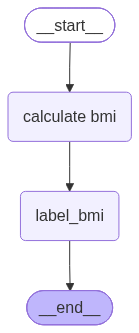

In [ ]:
workflow

In [ ]:
# initial state

intial_state = {'weight_kg': 80, 'height_m': 1.75}

In [ ]:
final_state = workflow.invoke(intial_state)

In [ ]:
final_state

{'weight_kg': 80, 'height_m': 1.75, 'bmi': 22.86, 'category': 'normal'}

In [ ]:
# Agentic Workflow

In [ ]:
# !pip install langchain_community

In [ ]:
from typing import Annotated, TypedDict
# from langchain_community.tools.tavilysearch import TavilySearchResults
from langchain_tavily import TavilySearch
from langgraph.prebuilt import ToolNode
from langchain_core.messages import BaseMessage


In [ ]:
from langchain_core.callbacks import BaseRunManager
# define state

from langgraph.graph.message import add_messages

class State(TypedDict):

  messages: Annotated[list[BaseMessage], add_messages]

In [ ]:
# initialize the model

llm = ChatGoogleGenerativeAI(
    model = "gemini-3.5-flash",
    temperature = 0,
    api_key = api_key,
    # max_output_tokens = 100
)

In [ ]:
tools = [search_tool]

In [ ]:
llm_with_tools = llm.bind_tools(tools)

In [ ]:
def call_model(state: State):
  response = llm_with_tools.invoke(state['messages'])

  return {"messages": [response]}

In [ ]:
def should_continue(state: State):
    last_message = state['messages'][-1]
    if last_message.tool_calls:
        return "tools"
    return END

In [ ]:
workflow = StateGraph(State)

In [ ]:
tool_node = ToolNode(tools)

In [ ]:
workflow = StateGraph(State)

workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

workflow.set_entry_point("agent")
workflow.add_conditional_edges("agent", should_continue)
workflow.add_edge("tools", "agent")

In [ ]:
app = workflow.compile()

In [ ]:
workflow

In [ ]:
from langchain_core.messages import HumanMessage, SystemMessage

system = SystemMessage(content = ("you are a helpful assistant"
"if you dont know the answer like whether or events then always use search tool"))

In [ ]:
input = {
    'messages': [system,
                 HumanMessage(content = "should i bring umbrealla tomorrow on 24 sep 2026, i live in pune,india")]
}

In [ ]:
for output in app.+input):
  print(output)

{'agent': {'messages': [AIMessage(content=[], additional_kwargs={'function_call': {'name': 'tavily_search', 'arguments': '{"query": "Pune weather forecast September 24 2026"}'}, '__gemini_function_call_thought_signatures__': {'call_333853': 'EpUHCpIHAWkUfRMYID7I0dzXXw7pHBKaNW0BdHVK8Y5J8xUVGhFZp1gslz2ENS2nlaJy3WL1xXdnmLdmoJJoW+aPi2wNXYUFxQhtsr4ZOUoxvsnc6POBNZl5I3YpdmEzSK8C0yEKcI0aHLFJnClsSD2UVA3nhPUBk/8rtH6F3Th1TnTedv7xjn8bQLVU3OJCsjTgRi4g5j8lWHT1dF5NyQSZCGerIGedCP+RSXkcoH1pC/9B3sU/aYwaEl1OdRpgHAwa0x7BpKsSakABZWcMwbITpvakCHyMcstKjCrGXMYVBXMv7LJ7ZIEe98f2KqqdPGNajo7yDA/iq89BDNi68MHOy9xs3dW0FIFhBQtGU55/gpS2LUi0cBRpLSnKEbzYXe05AKlCRnUATJKsEMO7IFFdYZR9xBBrQ2NQhIfvBRnhbFSoNA2mvzsmQi+sGE46jD8ySvDe6ciJwxbFFMmRiGqBpkNQS6rQjpqCQMJ/5PUYq4Og/nJ36nLXo4zvF9zG7w8QTYl9sVlTO+JlZ0lPSDP5ijtAbvhFhjBXzmoYa2DnIh//MqeVcY7PWR9/uk6vzmk/4Hhpvh5zQ4qQ17Kmuwqu3SU638IGwUoKaeSL1Q1YS+jO+bs0SgvmWv11RHOjGZomXxXiBaMCFJBDwJA3BrsT6XFBINV3+Scqf2LSWgwat9+eymw+JiRamgsYaa7Q5szJCIcVrtiZVtZGEmXhfOPzRRa+CWeb6L3JfsqGorFtV7q7ftL7o3